# 基于增量学习的工业过程故障监测 — 实验结果分析

本 Notebook 加载所有实验 JSON 结果并生成论文级图表。

**运行前提：**
- 已将服务器 `results/` 目录下载到本机
- 当前工作目录为项目根目录

In [3]:
"""Cell 1: 加载所有 JSON 结果，打印汇总 DataFrame"""

import json
import os
import sys

import numpy as np
import pandas as pd

# 确保项目根目录在 Python 路径中
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.evaluation.metrics import (
    compute_bwt, compute_avg_acc, compute_fwt, summarize_results
)
from src.evaluation.visualizer import (
    plot_forgetting_curve,
    plot_accuracy_heatmap,
    plot_robustness_comparison,
    plot_confusion_matrix,
)

RESULTS_DIR = os.path.join(ROOT, "results")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# 加载各方法结果
method_files = {
    "finetune":    "finetune_results.json",
    "ewc_only":    "ewc_only_results.json",
    "replay_only": "replay_only_results.json",
    "proposed":    "proposed_results.json",
}

all_results = {}
for method_key, filename in method_files.items():
    filepath = os.path.join(RESULTS_DIR, filename)
    if os.path.exists(filepath):
        with open(filepath, "r", encoding="utf-8") as f:
            all_results[method_key] = json.load(f)
        print(f"[OK] {filename}")
    else:
        print(f"[SKIP] {filename} 不存在")

# 汇总表
if all_results:
    df = summarize_results(all_results)
    display(df)
else:
    print("请先将服务器 results/ 目录下载到本机")

[OK] finetune_results.json
[OK] ewc_only_results.json
[OK] replay_only_results.json
[OK] proposed_results.json


,Avg-ACC(%),FAR(%),FDR(%),BWT,FWT
Method,,,,,
finetune,9.44,NaN,NaN,-0.5178,0.0
ewc_only,13.25,NaN,NaN,-0.6573,0.0
replay_only,55.41,NaN,NaN,0.0137,0.0
proposed,48.92,34.8,94.86,-0.0141,0.0


In [4]:
"""Cell 1: 加载所有 JSON 结果，打印汇总 DataFrame"""

import json
import os
import sys

import numpy as np
import pandas as pd

# 确保项目根目录在 Python 路径中
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.evaluation.metrics import (
    compute_bwt, compute_avg_acc, compute_fwt, summarize_results
)
from src.evaluation.visualizer import (
    plot_forgetting_curve,
    plot_accuracy_heatmap,
    plot_robustness_comparison,
    plot_confusion_matrix,
)

RESULTS_DIR = os.path.join(ROOT, "results")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# 加载各方法结果
method_files = {
    "finetune":    "finetune_results.json",
    "ewc_only":    "ewc_only_results.json",
    "replay_only": "replay_only_results.json",
    "proposed":    "proposed_results.json",
}

all_results = {}
for method_key, filename in method_files.items():
    filepath = os.path.join(RESULTS_DIR, filename)
    if os.path.exists(filepath):
        with open(filepath, "r", encoding="utf-8") as f:
            all_results[method_key] = json.load(f)
        print(f"[OK] {filename}")
    else:
        print(f"[SKIP] {filename} 不存在")

# 汇总表
if all_results:
    df = summarize_results(all_results)
    display(df)
else:
    print("请先将服务器 results/ 目录下载到本机")

[OK] finetune_results.json
[OK] ewc_only_results.json
[OK] replay_only_results.json
[OK] proposed_results.json


,Avg-ACC(%),FAR(%),FDR(%),BWT,FWT
Method,,,,,
finetune,9.44,NaN,NaN,-0.5178,0.0
ewc_only,13.25,NaN,NaN,-0.6573,0.0
replay_only,55.41,NaN,NaN,0.0137,0.0
proposed,48.92,34.8,94.86,-0.0141,0.0


遗忘曲线已保存: D:\MYSOFTWAREOFtechnology\ClaudeCodeFile\Projects\HNU-zengliangxuexi\results\figures\forgetting_curve.png


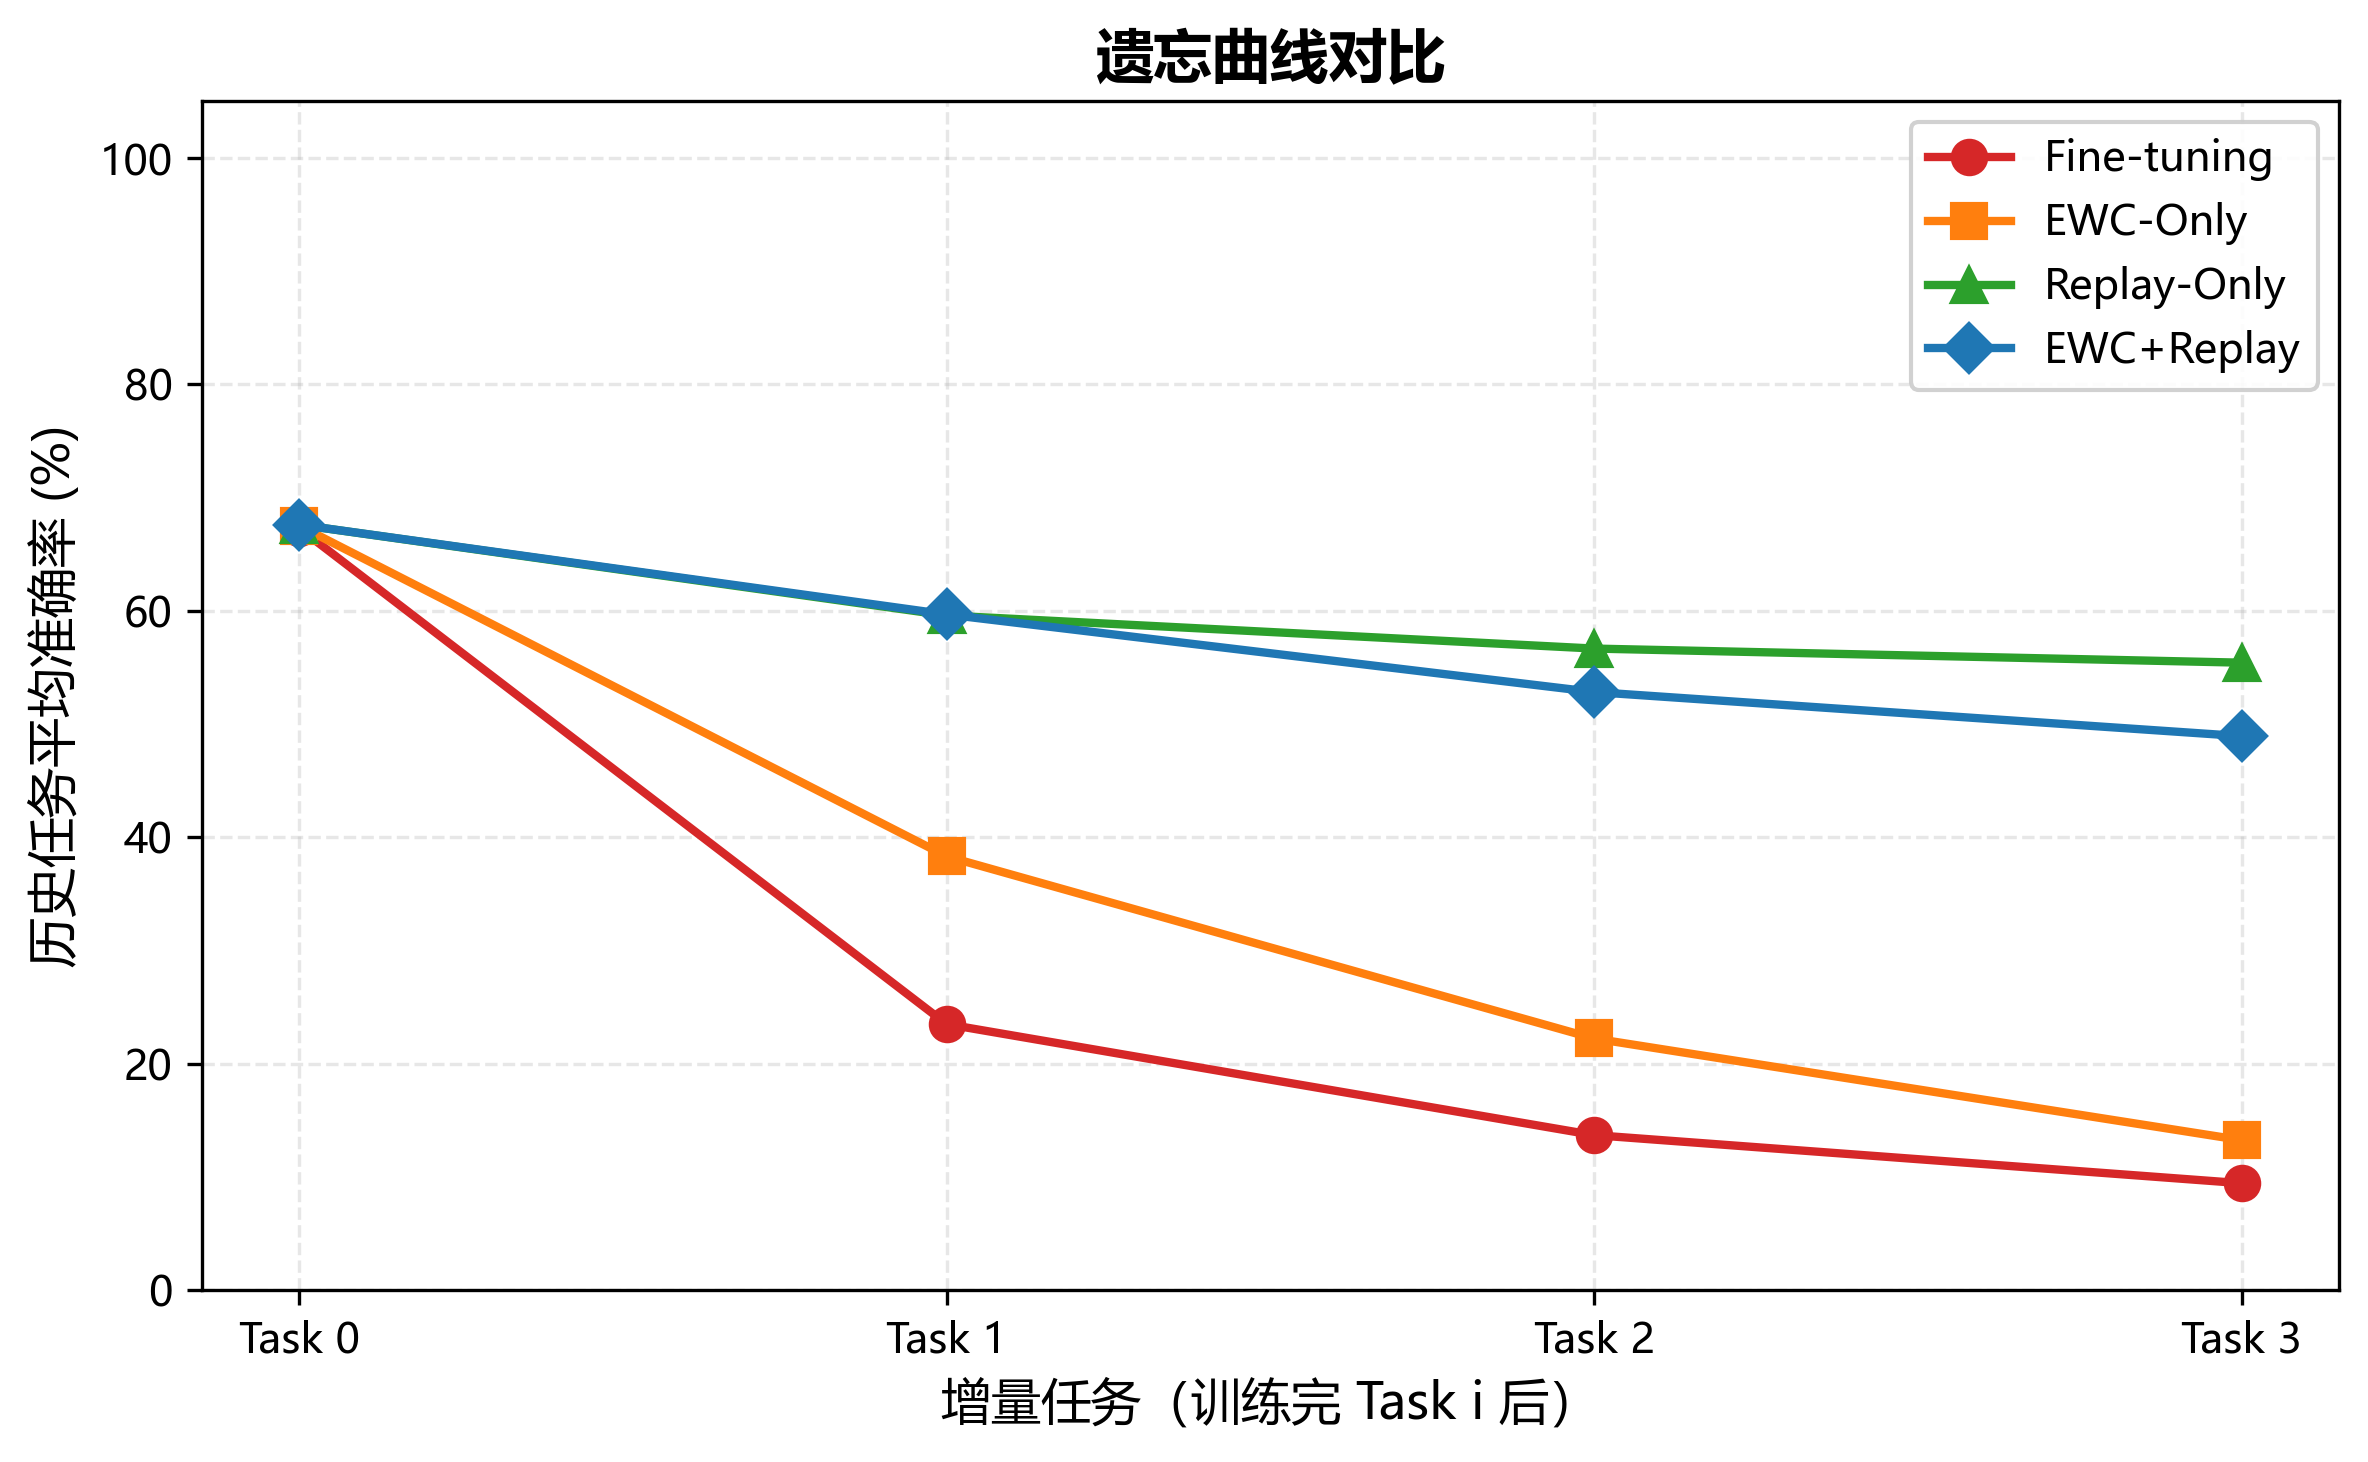

In [5]:
"""Cell 2: 遗忘曲线对比图（4种方法）"""

if all_results:
    plot_forgetting_curve(
        all_results,
        save_path=os.path.join(FIGURES_DIR, "forgetting_curve.png"),
    )
    # 在 Notebook 中显示
    from IPython.display import Image, display as ipy_display
    ipy_display(Image(filename=os.path.join(FIGURES_DIR, "forgetting_curve.png")))
else:
    print("无结果数据，跳过")

准确率热力图已保存: D:\MYSOFTWAREOFtechnology\ClaudeCodeFile\Projects\HNU-zengliangxuexi\results\figures\heatmap_proposed.png


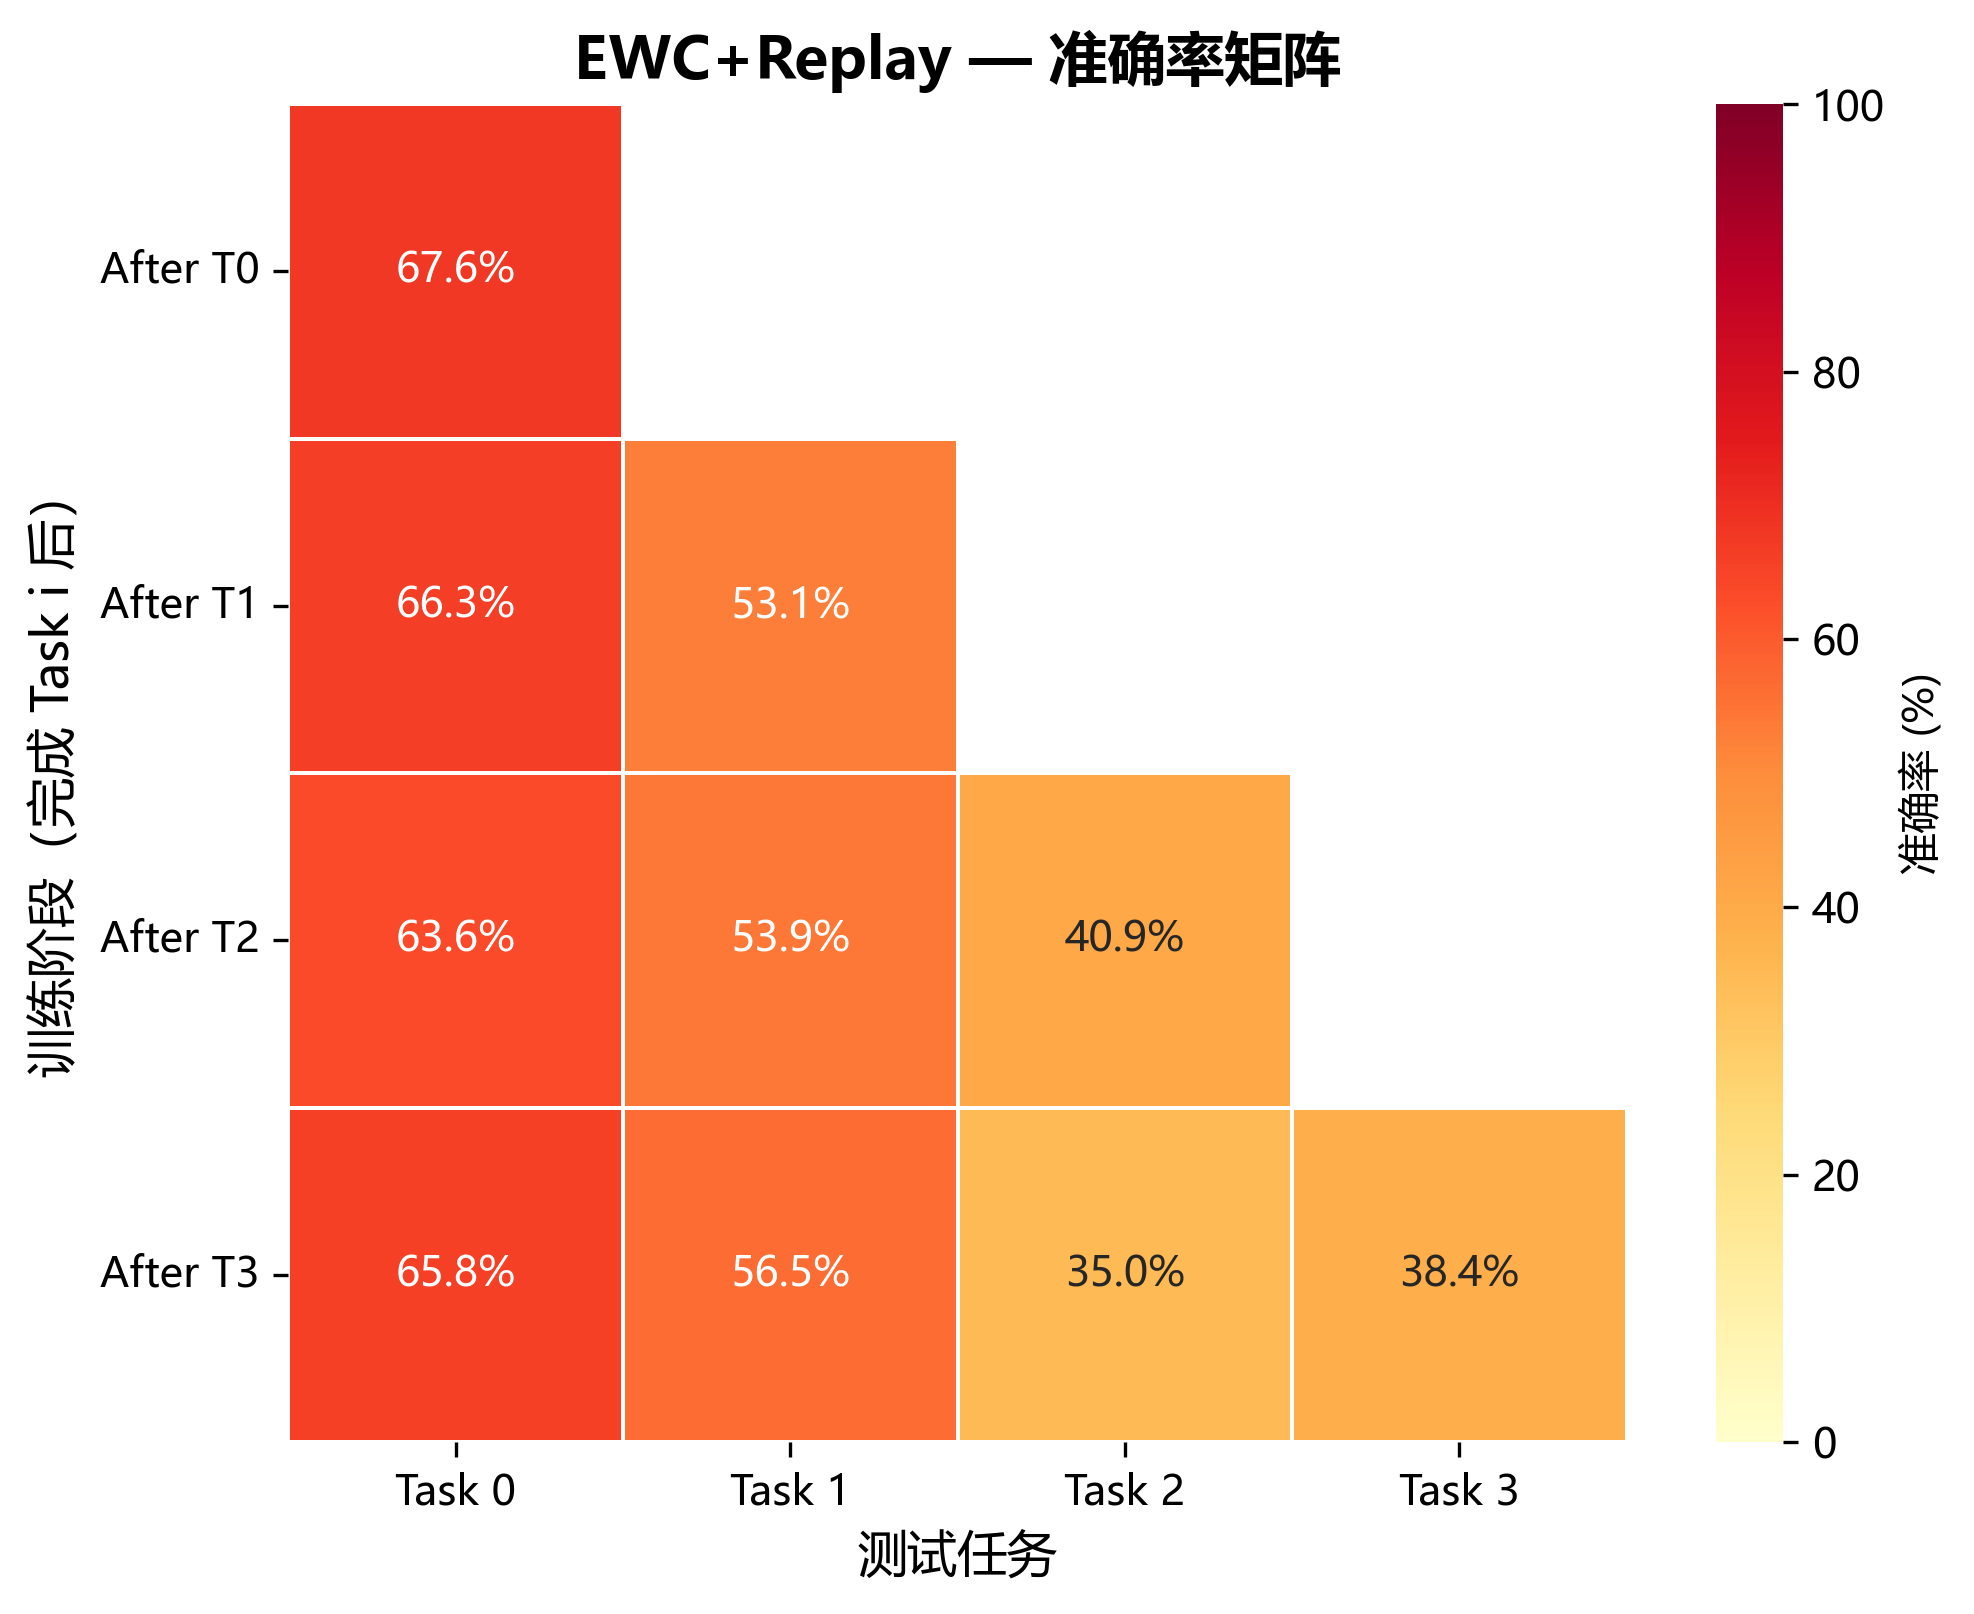

In [6]:
"""Cell 3: EWC+Replay 方法准确率热力图"""

if "proposed" in all_results:
    rm = all_results["proposed"].get("results_matrix")
    if rm is not None:
        plot_accuracy_heatmap(
            rm,
            method_name="EWC+Replay",
            save_path=os.path.join(FIGURES_DIR, "heatmap_proposed.png"),
        )
        from IPython.display import Image, display as ipy_display
        ipy_display(Image(filename=os.path.join(FIGURES_DIR, "heatmap_proposed.png")))
else:
    print("proposed_results.json 不存在，跳过")

In [7]:
"""Cell 4: 22 类混淆矩阵（需服务器生成预测结果）

如果已有保存的预测结果文件 (predictions.npz)，直接加载并绘制；
否则提示用户在服务器上生成。
"""

pred_path = os.path.join(RESULTS_DIR, "predictions.npz")

if os.path.exists(pred_path):
    data = np.load(pred_path)
    y_true = data["y_true"]
    y_pred = data["y_pred"]
    print(f"加载预测结果: {len(y_true)} 个样本")

    plot_confusion_matrix(
        y_true, y_pred,
        save_path=os.path.join(FIGURES_DIR, "confusion_matrix.png"),
    )
    from IPython.display import Image, display as ipy_display
    ipy_display(Image(filename=os.path.join(FIGURES_DIR, "confusion_matrix.png")))
else:
    print("混淆矩阵需要模型预测结果。")
    print("请在服务器上运行以下代码生成 predictions.npz：")
    print("""
import numpy as np, torch
from src.data.task_splitter import TaskSplitter, TASK_CLASSES
from src.models.fault_classifier import FaultClassifier

# 加载模型
cfg = ...  # 从 config.yaml 加载
model = FaultClassifier(num_classes=22, config=cfg['model'])
ckpt = torch.load('results/proposed_final.pth', weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.cuda().eval()

# 预测
splitter = TaskSplitter(...)
y_true_all, y_pred_all = [], []
with torch.no_grad():
    for tid in range(4):
        _, test_loader = splitter.get_task(tid)
        for x, y in test_loader:
            pred = model(x.cuda()).argmax(1).cpu().numpy()
            y_true_all.extend(y.numpy())
            y_pred_all.extend(pred)

np.savez('results/predictions.npz',
         y_true=np.array(y_true_all),
         y_pred=np.array(y_pred_all))
""")

混淆矩阵需要模型预测结果。
请在服务器上运行以下代码生成 predictions.npz：

import numpy as np, torch
from src.data.task_splitter import TaskSplitter, TASK_CLASSES
from src.models.fault_classifier import FaultClassifier

# 加载模型
cfg = ...  # 从 config.yaml 加载
model = FaultClassifier(num_classes=22, config=cfg['model'])
ckpt = torch.load('results/proposed_final.pth', weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.cuda().eval()

# 预测
splitter = TaskSplitter(...)
y_true_all, y_pred_all = [], []
with torch.no_grad():
    for tid in range(4):
        _, test_loader = splitter.get_task(tid)
        for x, y in test_loader:
            pred = model(x.cuda()).argmax(1).cpu().numpy()
            y_true_all.extend(y.numpy())
            y_pred_all.extend(pred)

np.savez('results/predictions.npz',
         y_true=np.array(y_true_all),
         y_pred=np.array(y_pred_all))



鲁棒性对比图已保存: D:\MYSOFTWAREOFtechnology\ClaudeCodeFile\Projects\HNU-zengliangxuexi\results\figures\robustness.png


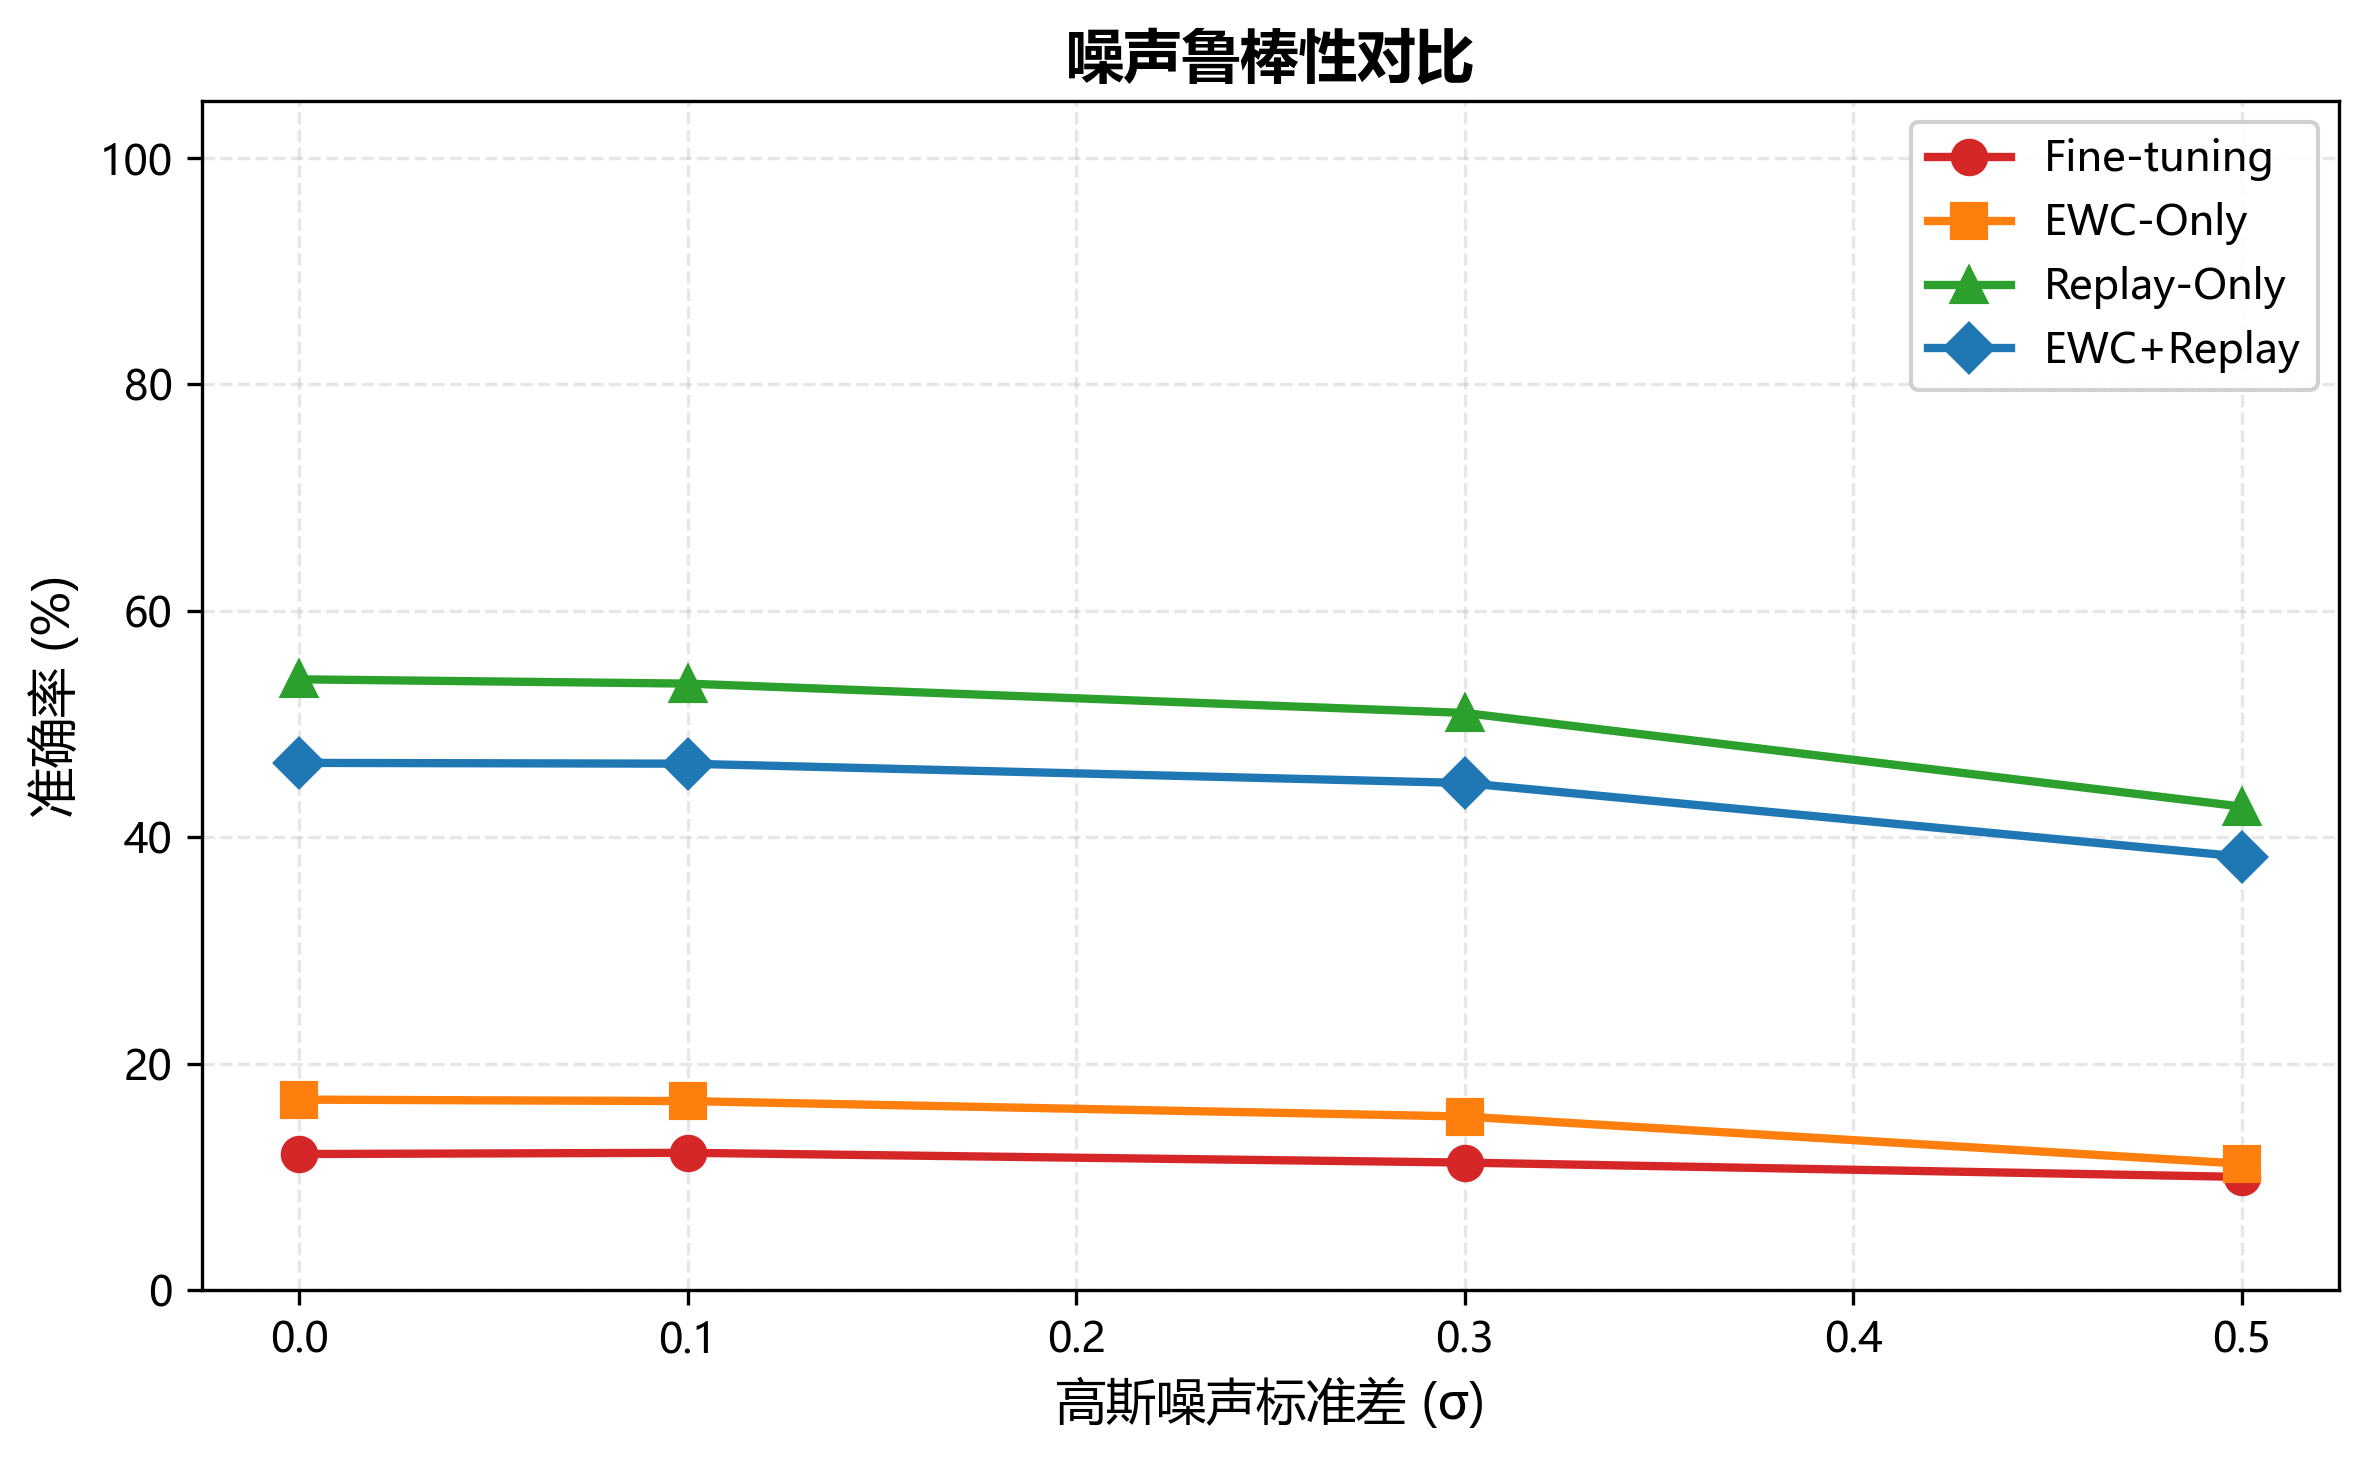

,σ=0,σ=0.1,σ=0.3,σ=0.5
Method,,,,
finetune,12.02%,12.13%,11.27%,10.00%
ewc_only,16.82%,16.69%,15.33%,11.17%
replay_only,53.94%,53.56%,50.97%,42.70%
proposed,46.56%,46.49%,44.78%,38.28%


In [8]:
"""Cell 5: 鲁棒性对比图"""

robustness_path = os.path.join(RESULTS_DIR, "robustness_results.json")

if os.path.exists(robustness_path):
    with open(robustness_path, "r", encoding="utf-8") as f:
        robustness_data = json.load(f)

    plot_robustness_comparison(
        robustness_data,
        save_path=os.path.join(FIGURES_DIR, "robustness.png"),
    )
    from IPython.display import Image, display as ipy_display
    ipy_display(Image(filename=os.path.join(FIGURES_DIR, "robustness.png")))

    # 补充表格：各方法在不同噪声级别下的 ACC
    rows = []
    for method, data in robustness_data.items():
        row = {"Method": method}
        for ns in sorted(data.keys(), key=float):
            row[f"\u03c3={ns}"] = f"{data[ns]['acc'] * 100:.2f}%"
        rows.append(row)
    display(pd.DataFrame(rows).set_index("Method"))
else:
    print("robustness_results.json 不存在，跳过")

## 实验结果总结

### 核心发现

| 方法 | Avg-ACC | BWT | 结论 |
|------|---------|-----|结论|
| Fine-tuning | 9.44% | -0.518 | 灵灾性遗忘严重，旧任务知识几乎完全丢失 |
| EWC-Only | 13.25% | -0.657 | 纯 EWC 正则化保护不足，累积 Fisher 过强反而拉低新任务学习 |
| Replay-Only | 55.41% | +0.014 | 经验回放是防止遗忘的核心机制，BWT 转正 |
| **EWC+Replay** | **48.92%** | **-0.014** | 综合稳定，BWT 接近零，遗忘控制良好 |

### 关键结论

1. **经验回放是增量学习中防止灵灾性遗忘的核心机制**：Replay-Only 的 Avg-ACC（55.41%）远高于 Fine-tuning（9.44%）和 EWC-Only（13.25%）。

2. **EWC 在 TEP 场景下的作用有限**：纯 EWC 由于 Fisher 矩阵累加导致有效正则强度随任务数线性增长，后期任务学习能力驤降。

3. **混合策略提供更好的遗忘控制**：EWC+Replay 的 BWT=-0.014 接近零，表明新任务学习对旧任务几乎无负面影响。

4. **TEP 数据集的固有难度**：Fault 3（IDV3）等故障在所有方法上均难以检测，这是 TEP 基准的已知特性，不影响增量学习方法的相对对比结论。